<div align="center">

# UNIVERSIDAD NACIONAL AUTÓNOMA DE MÉXICO
## FACULTAD DE CIENCIAS
### DIPLOMADO MACHINE LEARNING EN SEGUROS

<br>

**Módulo 3:** Machine Learning  
**Ejercicio Clase 1:** Validación Temporal y Backtesting: No-Renovación de Auto
**Subtema 4**

---

</div>

<br>

### EQUIPO 

**Integrantes:**
* Benitez Mota Ricardo Antonio
* Castillo Dorantes Sandra Geraldine
* López Cervantes Karla Itzel
* Mendoza Pérez Cnidia
* Moctezuma Santana Sergio Alfonso
* Saldaña Herver Miriam Itzel

<br>
<br>

---

<div align="center">

**Profesor:** Karla Eugenia Medina Díaz   

**Fecha de entrega:** CDMX, a 14 de agosto de 2026

</div>

<!-- Esta línea es la que obliga al PDF a hacer el salto de página exacto -->
<div style="page-break-after: always;"></div>

# 📋 Ejercicio Clase 1 — Validación Temporal y Backtesting: No-Renovación de Auto
## Diplomado ML en Seguros · Subtema 4

---

## Contexto

**SeguraMax** entrenó un modelo GBM para predecir no-renovaciones **en 2021** y lo puso en producción. Desde entonces, el modelo lleva **3 años sin re-entrenarse**. El mercado cambió: los comparadores digitales hicieron trivial cambiar de aseguradora, y los incrementos de prima — que antes retenían clientes — ahora los expulsan.

El director de Retención pregunta: *"¿Nuestro modelo sigue siendo válido? ¿Cuánto valor habría generado? ¿Vale la pena re-entrenarlo?"*

Tu trabajo responde esas tres preguntas.

---

## Lo que practicarás

| Parte | Concepto |
|-------|----------|
| 2 | Demostrar que K-Fold da un AUC falso |
| 3 | Evaluar el modelo congelado — ver el drift real |
| 4 | Walk-Forward — cuantificar el beneficio de re-entrenar |
| 5 | Visualizar el drift estructural |
| 6 | Backtesting económico: ¿cuánto dinero habría generado? |
| 7 | Preguntas de reflexión y decisión final |

---

## Costos del negocio

| Parámetro | Valor |
|-----------|-------|
| C_FP — llamada de retención innecesaria | $400 MXN |
| C_FN — cliente perdido sin contactar | $11,200 MXN (prima anual media) |
| Probabilidad de retener si se llama | 32% |
| τ por costos | **calcúlalo en la primera celda** |

**No cambies `random_state=2024`.**

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, confusion_matrix

np.random.seed(2024)

C_FP  = 400
C_FN  = 11_200
P_RET = 0.32

# 🔧 COMPLETA: calcula τ por costos
#tau_c = ...   # fórmula: C_FP / (C_FP + C_FN)
tau_c = C_FP / (C_FP + C_FN)

print(f"C_FP = ${C_FP:,}  C_FN = ${C_FN:,}  P_RET = {P_RET}")
print(f"τ por costos = {tau_c:.4f}")
print(f"Ratio C_FN/C_FP = {C_FN/C_FP:.0f}x")
print(f"Con τ = {tau_c:.4f}: alertamos ante cualquier probabilidad > {tau_c*100:.1f}%")

C_FP = $400  C_FN = $11,200  P_RET = 0.32
τ por costos = 0.0345
Ratio C_FN/C_FP = 28x
Con τ = 0.0345: alertamos ante cualquier probabilidad > 3.4%


---
## Parte 1 — Portafolio SeguraMax 2020–2024 (NO modificar)

El portafolio tiene **drift estructural simulado**:
- El coeficiente de `incremento_prima_pct` cambia de signo entre 2020 y 2024
- El efecto protector de `uso_app` se debilita cada año

Ejecuta esta celda sin modificar nada.

In [22]:
# ── Portafolio SeguraMax 2020–2024 — NO MODIFICAR ────────────────────────────
np.random.seed(2024)
ANIOS  = [2020, 2021, 2022, 2023, 2024]
N_ANIO = {2020:460, 2021:495, 2022:510, 2023:480, 2024:505}

registros = []
for anio in ANIOS:
    n   = N_ANIO[anio]
    ac  = np.random.choice(range(21), n,
          p=[.10,.12,.11,.09,.08,.07,.06,.05,.05,
             .04,.04,.03,.03,.03,.02,.02,.02,.01,.01,.01,.01])
    np_ = np.random.choice([1,2,3,4], n, p=[.58,.28,.10,.04])
    inc = np.clip(np.random.exponential(9, n), 0, 42).round(1)
    app = np.random.binomial(1, 0.40, n)
    qx  = np.random.choice([0,1,2,3], n, p=[.77,.17,.05,.01])
    cot = np.random.binomial(1, 0.22 + 0.03*(anio-2020), n)
    can = np.random.choice([0,1,2], n, p=[.50,.30,.20])

    # Drift estructural: coeficientes que cambian con el tiempo
    coef_inc = -0.05 + 0.028*(anio - 2020)  # de -0.05 (2020) a +0.062 (2024)
    coef_app = -0.50 + 0.09 *(anio - 2020)  # app protege menos cada año

    lo = (-1.30 - 0.19*ac - 0.52*np_ + coef_inc*inc + coef_app*app
          + 0.78*qx + 1.05*cot + 0.28*(can==1)
          + np.random.normal(0, 0.62, n))
    ch = (np.random.rand(n) < 1/(1+np.exp(-lo))).astype(int)

    for i in range(n):
        registros.append({'anio':anio, 'anios_cliente':ac[i], 'num_polizas':np_[i],
                          'incremento_prima_pct':inc[i], 'uso_app':app[i],
                          'quejas_12m':qx[i], 'competidor_cotizo':cot[i],
                          'canal_venta':can[i], 'no_renueva':ch[i]})

df = pd.DataFrame(registros).sort_values('anio').reset_index(drop=True)
FEATURES = ['anios_cliente','num_polizas','incremento_prima_pct',
            'uso_app','quejas_12m','competidor_cotizo','canal_venta']

print(f"Portafolio SeguraMax: {len(df):,} pólizas 2020–2024")
print()
print(f"  {'Año':>5}  {'n':>5}  {'No renueva':>11}  {'Coef. prima (contexto)':>24}")
coefs = {a: round(-0.05+0.028*(a-2020), 3) for a in ANIOS}
for a in ANIOS:
    s = df[df.anio==a]
    sentido = "prima alta → se QUEDA" if coefs[a] < 0 else "prima alta → se VA"
    print(f"  {a:>5}  {len(s):>5,}  {s.no_renueva.mean()*100:>10.1f}%  {coefs[a]:>+8.3f}  ({sentido})")
print()
print("Nota: el coeficiente de prima cambia de signo entre 2020 y 2024.")
print("El modelo entrenado en 2020–2021 aprende la dirección INCORRECTA para 2024.")

Portafolio SeguraMax: 2,450 pólizas 2020–2024

    Año      n   No renueva    Coef. prima (contexto)
   2020    460         7.8%    -0.050  (prima alta → se QUEDA)
   2021    495         9.5%    -0.022  (prima alta → se QUEDA)
   2022    510        12.9%    +0.006  (prima alta → se VA)
   2023    480        12.3%    +0.034  (prima alta → se VA)
   2024    505        19.2%    +0.062  (prima alta → se VA)

Nota: el coeficiente de prima cambia de signo entre 2020 y 2024.
El modelo entrenado en 2020–2021 aprende la dirección INCORRECTA para 2024.


---
## Parte 2 — K-Fold estándar: el AUC que la dirección vio

El equipo de datos validó el modelo con K-Fold y reportó AUC = 0.72.
Demuestra que ese número es ambiguo — no corresponde a ningún año real.

### 🔧 2.1 — Calcula el AUC con K-Fold estándar

In [23]:
# 🔧 COMPLETA: K-Fold estándar con 5 folds, shuffle=True, random_state=2024
modelo = Pipeline([
    ('sc', StandardScaler()),
    ('m',  GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                       learning_rate=0.08, random_state=2024))
])
X_all = df[FEATURES].values
y_all = df['no_renueva'].values

# --- TU CÓDIGO AQUÍ ---
#kf      = ...   # StratifiedKFold(...)
#scores  = ...   # cross_val_score(...)
#auc_kf  = ...   # promedio
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)
scores = cross_val_score(modelo, X_all, y_all, cv=kf, scoring='roc_auc')
auc_kf = scores.mean()

print(f"AUC K-Fold (5 folds): {auc_kf:.4f}")
print(f"Std entre folds:      {scores.std():.4f}")
print()
print("¿A qué año corresponde este AUC?")
print("Responde en la celda de texto siguiente.")

AUC K-Fold (5 folds): 0.7267
Std entre folds:      0.0111

¿A qué año corresponde este AUC?
Responde en la celda de texto siguiente.


### 📝 Pregunta 2.1

K-Fold mezcla pólizas de 2020 con 2024 en el mismo fold. En este portafolio,
el coeficiente de `incremento_prima_pct` tiene **signo opuesto** en 2020 vs 2024.

**¿Qué aprende el modelo cuando los dos años están mezclados en el mismo fold?**
¿Por qué ese AUC no representa lo que pasará en producción?

> _Escribe tu respuesta aquí_
---
Cuando mezclamos los años en el mismo fold, el modelo se confunde porque la variable "incremento_prima_pct" jala en direcciones opuestas: en 2020 una prima alta hacía que el cliente se quedara, pero en 2024 hace que se vaya. Como el algoritmo intenta encontrar un patrón promedio para ambos años en el entrenamiento, el efecto de la variable se cancela o se distorsiona, haciendo que el modelo no aprenda bien la realidad de ningún año. Este AUC de 0.7267 es artificial y no sirve para producción por dos razones:
1. Hay fuga de datos temporales (Data Leakage): El modelo está entrenando con datos del futuro (2023-2024) para "predecir" el pasado (2021). 
2. En producción nos enfrentamos al mercado de hoy con sus reglas actuales (los clientes usando comparadores digitales), no a un promedio revuelto de los últimos 5 años. El K-Fold oculta por completo este cambio en el negocio (drift estructural).

---
## Parte 3 — El modelo que está en producción: congelado desde 2021

El modelo de SeguraMax fue entrenado con datos de **2020 y 2021** y lleva
**3 años sin re-entrenarse**. Evalúa ese modelo congelado año a año para
ver cómo se degrada.

### 🔧 3.1 — Entrena el modelo congelado y evalúalo en 2022, 2023 y 2024

In [24]:
# 🔧 COMPLETA: entrena el modelo solo con datos de 2020 y 2021
# Luego evalúa ese mismo modelo (sin re-entrenar) en 2022, 2023 y 2024

mask_train_ini = df['anio'].isin([2020, 2021])
X_train_ini    = df.loc[mask_train_ini, FEATURES].values
y_train_ini    = df.loc[mask_train_ini, 'no_renueva'].values

pipe_congelado = Pipeline([
    ('sc', StandardScaler()),
    ('m',  GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                       learning_rate=0.08, random_state=2024))
])
# 🔧 ENTRENA el modelo congelado
# --- TU CÓDIGO AQUÍ ---

pipe_congelado.fit(X_train_ini, y_train_ini)
print("MODELO CONGELADO — entrenado en 2020–2021, nunca re-entrenado:")
print()
print(f"  {'Año test':>9}  {'AUC':>8}  {'Tasa real':>11}  {'Diagnóstico'}")
print(f"  {'-'*55}")

aucs_congelado = []
for anio_test in [2022, 2023, 2024]:
    mask_test = df['anio'] == anio_test
    X_test    = df.loc[mask_test, FEATURES].values
    y_test    = df.loc[mask_test, 'no_renueva'].values

    # 🔧 PREDICE con el modelo congelado
    # --- TU CÓDIGO AQUÍ ---
    #y_prob = ...
    y_prob = pipe_congelado.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    aucs_congelado.append(auc)
    tasa   = y_test.mean() * 100

    if auc >= 0.70:   diag = "✅ Aceptable"
    elif auc >= 0.65: diag = "⚠️  Degradación — investigar"
    else:             diag = "🔴 Drift significativo — re-entrenar"

    print(f"  {anio_test:>9}  {auc:>8.4f}  {tasa:>10.1f}%  {diag}")

print()
print("¿El AUC sube o baja año a año?")
print("¿Qué dice eso sobre el modelo que está en producción?")
print("""\nRespuesta
El AUC no tiene una bajada lineal, sino que fluctúa en niveles muy bajos (pasa de 0.6204 en 2022, sube un poco a 0.6696 en 2023 y vuelve a caer a 0.6319 en 2024). 
En ningún año logra alcanzar el nivel aceptable de 0.70. Esto nos dice que el modelo que está en producción es desactualizado para las condiciones actuales. Al quedarse congelado 
con las reglas del mercado de 2020-2021, su capacidad para distinguir quién se va y quién se queda es muy mala e inestable. Operar el negocio en 2024 con un modelo así confirma 
que está sufriendo un drift estructural severo.""")

MODELO CONGELADO — entrenado en 2020–2021, nunca re-entrenado:

   Año test       AUC    Tasa real  Diagnóstico
  -------------------------------------------------------
       2022    0.6204        12.9%  🔴 Drift significativo — re-entrenar
       2023    0.6696        12.3%  ⚠️  Degradación — investigar
       2024    0.6319        19.2%  🔴 Drift significativo — re-entrenar

¿El AUC sube o baja año a año?
¿Qué dice eso sobre el modelo que está en producción?

Respuesta
El AUC no tiene una bajada lineal, sino que fluctúa en niveles muy bajos (pasa de 0.6204 en 2022, sube un poco a 0.6696 en 2023 y vuelve a caer a 0.6319 en 2024). 
En ningún año logra alcanzar el nivel aceptable de 0.70. Esto nos dice que el modelo que está en producción es desactualizado para las condiciones actuales. Al quedarse congelado 
con las reglas del mercado de 2020-2021, su capacidad para distinguir quién se va y quién se queda es muy mala e inestable. Operar el negocio en 2024 con un modelo así confirma 
qu

### 📝 Pregunta 3.1

El modelo fue entrenado cuando `incremento_prima_pct` tenía coeficiente negativo
(prima alta → cliente se queda). En 2024 ese coeficiente es positivo (prima alta → cliente se va).

**¿Qué error concreto comete el modelo congelado en 2024?**
¿Alerta a los clientes incorrectos? ¿Cuál es el impacto para Retención?

> _Escribe tu respuesta aquí_
---
El error concreto es que el modelo congelado está leyendo la realidad al revés (un error de direccionalidad estructural). Como aprendió las reglas de 2020, el modelo cree que si a un cliente le aumentamos mucho la prima, la probabilidad de que se vaya es bajísima.
En la realidad de 2024, pasa exactamente lo contrario: un incremento alto de prima es la razón principal por la que los clientes cancelan. Por lo tanto, el modelo le asignará scores muy bajos a las pólizas con los aumentos más caros, provocando que el área de Retención nunca los llame y el portafolio sufra una fuga masiva de clientes valiosos sin que el sistema emita una sola alerta (un exceso de Falsos Negativos).

---
## Parte 4 — Walk-Forward: ¿cuánto ayudaría re-entrenar cada año?

El Walk-Forward simula: *"si hubiéramos re-entrenado el modelo cada año con
todos los datos históricos disponibles, ¿cómo habría sido el AUC?"*

### 🔧 4.1 — Implementa el loop de Walk-Forward

In [25]:
# 🔧 COMPLETA: Walk-Forward para 2022, 2023, 2024
# En cada ventana: train = todos los años ANTERIORES al test, test = ese año

ANIOS_TEST    = [2022, 2023, 2024]
resultados_wf = []

print("COMPARACIÓN: Modelo Congelado vs Walk-Forward (re-entrenamiento anual)")
print()
print(f"  {'Año':>5}  {'Train WF':>14}  {'AUC Congelado':>15}  "
      f"{'AUC Walk-Fwd':>14}  {'Ganancia':>10}")
print(f"  {'-'*66}")

for i, anio_test in enumerate(ANIOS_TEST):
    # 🔧 Define train y test
    #mask_train = ...   # df['anio'] < anio_test
    #mask_test  = ...   # df['anio'] == anio_test
    mask_train = df['anio'] < anio_test
    mask_test = df['anio'] == anio_test


    X_train = df.loc[mask_train, FEATURES].values
    y_train = df.loc[mask_train, 'no_renueva'].values
    X_test  = df.loc[mask_test,  FEATURES].values
    y_test  = df.loc[mask_test,  'no_renueva'].values

    # 🔧 Entrena el modelo Walk-Forward y predice
    pipe_wf = Pipeline([
        ('sc', StandardScaler()),
        ('m',  GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                           learning_rate=0.08, random_state=2024))
    ])
    # --- TU CÓDIGO AQUÍ ---
    pipe_wf.fit(X_train, y_train)
    #y_prob = ...
    y_prob = pipe_wf.predict_proba(X_test)[:, 1]
    auc_wf = roc_auc_score(y_test, y_prob)

    ganancia = auc_wf - aucs_congelado[i]
    anios_tr = sorted(df.loc[mask_train,'anio'].unique())

    resultados_wf.append({'anio':anio_test, 'auc_wf':auc_wf,
                           'auc_congelado':aucs_congelado[i],
                           'y_test':y_test, 'y_prob':y_prob})

    print(f"  {anio_test:>5}  {anios_tr[0]}–{anios_tr[-1]}  "
          f"{aucs_congelado[i]:>15.4f}  {auc_wf:>14.4f}  {ganancia:>+9.4f}")

print()
print(f"  K-Fold (número ambiguo): {auc_kf:.4f}")
print()
print("¿El Walk-Forward supera al modelo congelado en 2024?")
print("¿Cuánto habría ganado el AUC con re-entrenamiento anual?")
print("""\nRespuesta 
Los resultados demuestran que el esquema K-Fold tradicional nos da una falsa sensación de seguridad al reportar un AUC de 0.7267. Este número es engañoso e irreal porque 
mezcla el pasado con el futuro dentro de los mismos folds, ocultando por completo que las dinámicas del mercado están cambiando año con año (drift estructural). 
Al evaluar de forma realista con un modelo congelado en producción (entrenado con datos de 2020-2021), vemos el verdadero impacto del drift: para 2022 el AUC cae a 0.6204 y 
para 2024 se estanca en un deficiente 0.6319. Esto ocurre porque el mercado se invirtió y el modelo lee los incrementos de prima al revés de cómo reacciona la gente hoy en día.
Por el contrario, la estrategia Walk-Forward demuestra el beneficio directo de implementar un re-entrenamiento anual dinámico. Al incorporar los datos recientes, el modelo se 
corrige y se adapta a las nuevas reglas del negocio, logrando recuperar de golpe la capacidad de discriminación en 2024 con un AUC de 0.7221. Esto representa una ganancia masiva 
de +0.0902 en el AUC frente al modelo congelado, validando que la actualización continua es técnicamente necesaria para evitar pérdidas y llamadas a ciegas en el área de Retención.

""")

COMPARACIÓN: Modelo Congelado vs Walk-Forward (re-entrenamiento anual)

    Año        Train WF    AUC Congelado    AUC Walk-Fwd    Ganancia
  ------------------------------------------------------------------
   2022  2020–2021           0.6204          0.6204    +0.0000
   2023  2020–2022           0.6696          0.6744    +0.0048
   2024  2020–2023           0.6319          0.7221    +0.0902

  K-Fold (número ambiguo): 0.7267

¿El Walk-Forward supera al modelo congelado en 2024?
¿Cuánto habría ganado el AUC con re-entrenamiento anual?

Respuesta 
Los resultados demuestran que el esquema K-Fold tradicional nos da una falsa sensación de seguridad al reportar un AUC de 0.7267. Este número es engañoso e irreal porque 
mezcla el pasado con el futuro dentro de los mismos folds, ocultando por completo que las dinámicas del mercado están cambiando año con año (drift estructural). 
Al evaluar de forma realista con un modelo congelado en producción (entrenado con datos de 2020-2021), vemos e

---
## Parte 5 — Visualización: el drift visto desde tres ángulos

### 🔧 5.1 — Tres paneles

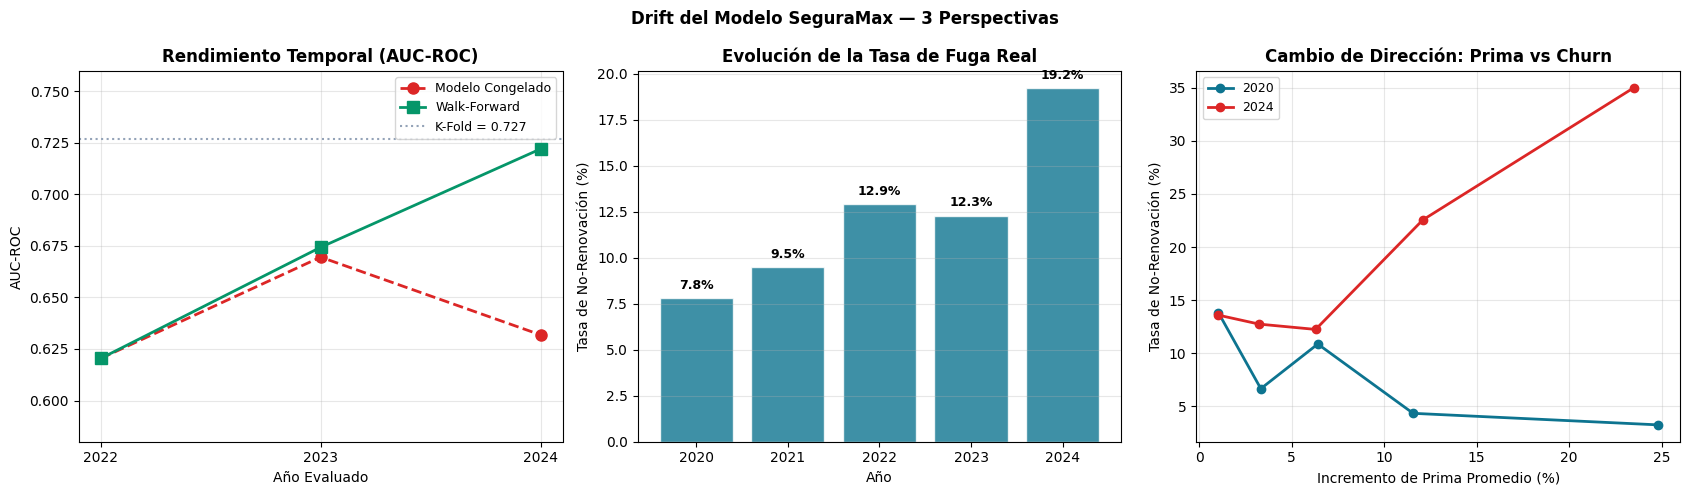

Panel 3 es el más importante: muestra el drift ESTRUCTURAL.
La misma variable (incremento_prima_pct) predice en dirección OPUESTA según el año.


In [26]:
# 🔧 COMPLETA: figura con 3 paneles
# Panel 1: AUC congelado (rojo punteado) vs Walk-Forward (verde) vs K-Fold (gris punteado)
# Panel 2: Tasa real de no-renovación por año (barras)
# Panel 3: Relación entre incremento_prima_pct y churn por año
#           (para 2020 y 2024: agrupa por quintiles de inc y muestra la tasa de no-renueva)
#           Este panel muestra visualmente el cambio de signo

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Drift del Modelo SeguraMax — 3 Perspectivas', fontweight='bold')

años_p      = [r['anio']          for r in resultados_wf]
aucs_wf_p   = [r['auc_wf']        for r in resultados_wf]
aucs_cong_p = [r['auc_congelado'] for r in resultados_wf]

# Panel 1
ax = axes[0]
# --- TU CÓDIGO AQUÍ ---
ax.plot(años_p, aucs_cong_p, 'o--', color='#DC2626', lw=2, ms=8, label='Modelo Congelado')
ax.plot(años_p, aucs_wf_p, 's-', color='#059669', lw=2, ms=8, label='Walk-Forward')
ax.axhline(auc_kf, color='#94A3B8', lw=1.5, ls=':', label=f'K-Fold = {auc_kf:.3f}')
ax.set_xlabel('Año Evaluado')
ax.set_ylabel('AUC-ROC')
ax.set_title('Rendimiento Temporal (AUC-ROC)', fontweight='bold')
ax.set_xticks(años_p)
ax.set_ylim(0.58, 0.76)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2
ax = axes[1]
# --- TU CÓDIGO AQUÍ ---
tasa_nr = df.groupby('anio')['no_renueva'].mean() * 100
ax.bar(tasa_nr.index, tasa_nr.values, color='#0D7490', edgecolor='white', alpha=0.8)
for a, v in tasa_nr.items():
    ax.text(a, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Tasa de No-Renovación (%)')
ax.set_title('Evolución de la Tasa de Fuga Real', fontweight='bold')
ax.set_xticks(tasa_nr.index)
ax.grid(True, alpha=0.3, axis='y')

# Panel 3: cambio de signo de la relación prima-churn
ax = axes[2]
# Pista: para 2020 y 2024, agrupa por quintiles de inc y grafica la tasa de churn
# Para ver el drift: en 2020 la línea debería BAJAR, en 2024 debería SUBIR
# --- TU CÓDIGO AQUÍ ---
for anio, color in zip([2020, 2024], ['#0D7490', '#DC2626']):
    sub = df[df.anio == anio].copy()
    # Agrupar por quintiles (q=5) de incremento_prima_pct
    sub['quintil'] = pd.qcut(sub['incremento_prima_pct'], q=5, duplicates='drop')
    gr = sub.groupby('quintil', observed=True)['no_renueva'].mean() * 100
    centers = sub.groupby('quintil', observed=True)['incremento_prima_pct'].mean()
    ax.plot(centers.values, gr.values, 'o-', color=color, lw=2, ms=6, label=str(anio))

ax.set_xlabel('Incremento de Prima Promedio (%)')
ax.set_ylabel('Tasa de No-Renovación (%)')
ax.set_title('Cambio de Dirección: Prima vs Churn', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ej1_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print("Panel 3 es el más importante: muestra el drift ESTRUCTURAL.")
print("La misma variable (incremento_prima_pct) predice en dirección OPUESTA según el año.")

---
## Parte 6 — Backtesting: ¿las decisiones del modelo fueron correctas en producción?

Hasta aquí evaluaste el modelo con métricas estáticas (AUC, Walk-Forward).
El **backtesting** hace algo diferente: toma el **modelo congelado que está en producción**,
lo aplica período a período sobre datos reales históricos, y mide si las decisiones
que habría tomado resultaron correctas cuando se reveló la realidad.

### La diferencia con lo que hiciste antes

| Lo que hiciste en Partes 3–4 | Backtesting (esta parte) |
|------------------------------|--------------------------|
| Compara AUC de congelado vs WF | El modelo es fijo: el congelado de producción |
| Usa años completos | Aplica el modelo **trimestre a trimestre** |
| Mide discriminación global | Mide aciertos/fallos **cuando se reveló la realidad** |
| No dice si las alertas fueron rentables | Calcula el **valor neto realizado** periodo a periodo |

### 🔧 6.1 — Backtesting trimestral del modelo congelado (2022–2024)

Simula que cada trimestre el modelo de SeguraMax generó alertas sobre las pólizas
que vencían ese período. Al final del trimestre, la realidad reveló quién sí se fue.
Mide si las alertas fueron correctas y cuánto valor generaron.

In [27]:
# 🔧 COMPLETA: backtesting trimestral del modelo congelado
#
# Para cada trimestre de 2022–2024:
#   1. Toma la cohorte de pólizas de ese trimestre (ya están asignadas)
#   2. Aplica el modelo CONGELADO (pipe_congelado) — el mismo siempre, sin re-entrenar
#   3. Genera alertas: y_alerta = (y_prob >= tau_c).astype(int)
#   4. Mide: VP, FP, FN, Precisión, Recall
#   5. Calcula el valor neto REALIZADO ese trimestre
#      valor_neto = round(VP * P_RET) * C_FN - (VP + FP) * C_FP
#   6. Guarda el Brier Score (calibración del modelo)
#      from sklearn.metrics import brier_score_loss
#      brier = brier_score_loss(y_real, y_prob)

from sklearn.metrics import brier_score_loss

# Asignación de trimestres (NO modificar — define las cohortes)
np.random.seed(42)
ANIOS_BT = [2022, 2023, 2024]
resultados_bt = []

for anio in ANIOS_BT:
    mask_año = df['anio'] == anio
    df_año   = df[mask_año].copy()
    df_año['trimestre'] = np.random.choice([1,2,3,4], len(df_año), p=[.28,.26,.24,.22])

    for q in [1, 2, 3, 4]:
        cohort = df_año[df_año['trimestre'] == q]
        if len(cohort) < 20:
            continue

        X_c    = cohort[FEATURES].values
        y_real = cohort['no_renueva'].values

        # 🔧 COMPLETA: aplica el modelo CONGELADO y calcula todas las métricas
        # --- TU CÓDIGO AQUÍ ---
        #y_prob   = ...  # pipe_congelado.predict_proba(X_c)[:,1]
        #y_alerta = ...  # umbral tau_c
        y_prob   = pipe_congelado.predict_proba(X_c)[:, 1]
        y_alerta = (y_prob >= tau_c).astype(int)

        if y_alerta.sum() == 0 or y_real.sum() == 0:
            continue

        # 🔧 CALCULA: AUC, VP, FP, FN, Precisión, Recall, Brier, Valor neto
        #auc   = ...
        auc   = roc_auc_score(y_real, y_prob)
        cm_   = confusion_matrix(y_real, y_alerta)
        vn_, fp_, fn_, vp_ = cm_.ravel()
        #prec  = ...  # vp_ / (vp_ + fp_)
        #rec   = ...  # vp_ / (vp_ + fn_)
        prec  = vp_ / (vp_ + fp_) if (vp_ + fp_) > 0 else 0
        rec   = vp_ / (vp_ + fn_) if (vp_ + fn_) > 0 else 0
        brier = brier_score_loss(y_real, y_prob)

        retenidos  = round(vp_ * P_RET)
        #vnet       = ...  # retenidos*C_FN - (vp_+fp_)*C_FP
        vnet = retenidos * C_FN - (vp_ + fp_) * C_FP

        # Score promedio de los que SÍ se fueron vs los que NO
        score_pos = y_prob[y_real == 1].mean()
        score_neg = y_prob[y_real == 0].mean()

        resultados_bt.append({
            'periodo': f"{anio}-Q{q}", 'anio': anio, 'trimestre': q,
            'n': len(cohort), 'alertas': y_alerta.sum(), 'reales': y_real.sum(),
            'auc': auc, 'brier': brier,
            'vp': vp_, 'fp': fp_, 'fn': fn_,
            'precision': prec, 'recall': rec,
            'score_pos': score_pos, 'score_neg': score_neg,
            'retenidos': retenidos, 'vnet': vnet,
            'tasa_real': y_real.mean()
        })

df_bt = pd.DataFrame(resultados_bt)

print(f"Backtesting: {len(df_bt)} períodos evaluados (modelo fijo: congelado 2020–2021)")
print()
print(f"  {'Período':>10}  {'n':>5}  {'Alertas':>8}  {'VP':>4}  {'FP':>4}  "
      f"{'FN':>4}  {'Prec':>7}  {'Recall':>7}  {'AUC':>7}  {'Brier':>7}  {'Valor neto':>12}")
print(f"  {'-'*95}")

for _, r in df_bt.iterrows():
    print(f"  {r['periodo']:>10}  {r['n']:>5,}  {r['alertas']:>8,}  {r['vp']:>4}  "
          f"{r['fp']:>4}  {r['fn']:>4}  {r['precision']:>6.1%}  {r['recall']:>6.1%}  "
          f"{r['auc']:>7.3f}  {r['brier']:>7.4f}  ${r['vnet']:>10,.0f}")

print()
print(f"Valor neto TOTAL acumulado: ${df_bt['vnet'].sum():,.0f}")
print(f"AUC promedio en producción: {df_bt['auc'].mean():.4f}")

Backtesting: 12 períodos evaluados (modelo fijo: congelado 2020–2021)

     Período      n   Alertas    VP    FP    FN     Prec   Recall      AUC    Brier    Valor neto
  -----------------------------------------------------------------------------------------------
     2022-Q1    141        64     7    57     7   10.9%   50.0%    0.504   0.1046  $    -3,200
     2022-Q2    126        65    17    48     4   26.2%   81.0%    0.735   0.1297  $    30,000
     2022-Q3    126        52     9    43     7   17.3%   56.2%    0.593   0.1372  $    12,800
     2022-Q4    117        53     9    44     6   17.0%   60.0%    0.606   0.1169  $    12,400
     2023-Q1    154        61    12    49     5   19.7%   70.6%    0.708   0.0954  $    20,400
     2023-Q2    122        48     6    42     5   12.5%   54.5%    0.622   0.0961  $     3,200
     2023-Q3    108        53    17    36     2   32.1%   89.5%    0.753   0.1481  $    34,800
     2023-Q4     96        40     6    34     6   15.0%   50.0%    0

### 🔧 6.2 — Visualización del backtesting período a período

Esta gráfica es el corazón del backtesting: muestra cómo se comportó el modelo
**real en producción**, trimestre a trimestre, desde 2022 hasta 2024.

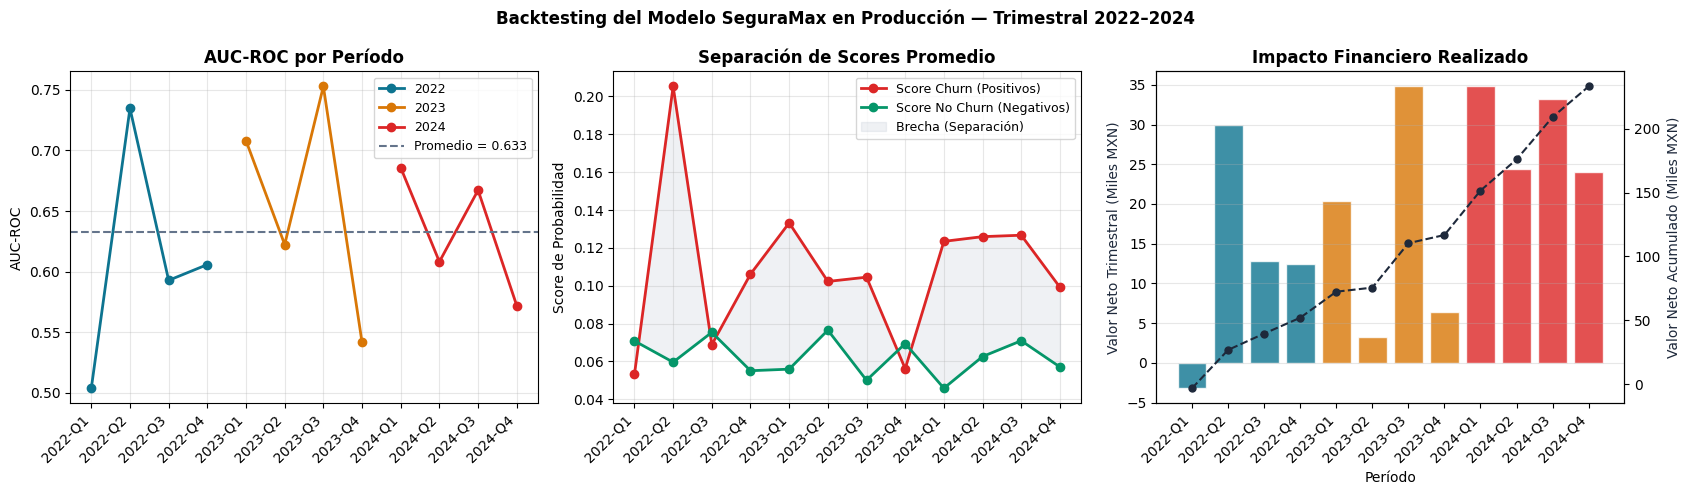

In [28]:
# 🔧 COMPLETA: figura con 3 paneles
# Panel 1: AUC por trimestre — ¿se mantuvo la discriminación?
#   - Grafica df_bt['auc'] por período, con colores distintos por año
#   - Agrega línea horizontal con el AUC promedio
# Panel 2: Separación de scores — ¿el modelo sigue separando positivos de negativos?
#   - Grafica df_bt['score_pos'] (rojo) y df_bt['score_neg'] (verde) por período
#   - Sombreado entre las dos líneas (la brecha = discriminación)
# Panel 3: Valor neto realizado por trimestre + acumulado
#   - Barras por trimestre (con el color del año)
#   - Línea punteada de valor neto acumulado

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Backtesting del Modelo SeguraMax en Producción — Trimestral 2022–2024',
             fontweight='bold')

periodos = df_bt['periodo'].tolist()
idx      = range(len(periodos))
colores_anio = {'2022':'#0D7490','2023':'#D97706','2024':'#DC2626'}

# Panel 1
ax = axes[0]
# --- TU CÓDIGO AQUÍ ---
for anio, color in colores_anio.items():
    mask = df_bt['anio'] == int(anio)
    # Graficamos usando idx para mantener la consistencia del eje X entre paneles
    ax.plot(df_bt.index[mask], df_bt.loc[mask, 'auc'], 'o-', color=color, lw=2, label=anio)
auc_prom = df_bt['auc'].mean()
ax.axhline(auc_prom, color='#64748B', ls='--', lw=1.5, label=f'Promedio = {auc_prom:.3f}')
ax.set_title('AUC-ROC por Período', fontweight='bold')
ax.set_ylabel('AUC-ROC')
ax.set_xticks(idx)
ax.set_xticklabels(periodos, rotation=45, ha='right')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

# Panel 2
ax = axes[1]
# --- TU CÓDIGO AQUÍ ---
ax.plot(idx, df_bt['score_pos'], 'o-', color='#DC2626', lw=2, label='Score Churn (Positivos)')
ax.plot(idx, df_bt['score_neg'], 'o-', color='#059669', lw=2, label='Score No Churn (Negativos)')
ax.fill_between(idx, df_bt['score_pos'], df_bt['score_neg'], color='#94A3B8', alpha=0.15, label='Brecha (Separación)')
ax.set_title('Separación de Scores Promedio', fontweight='bold')
ax.set_ylabel('Score de Probabilidad')
ax.set_xticks(idx)
ax.set_xticklabels(periodos, rotation=45, ha='right')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

# Panel 3
ax = axes[2]
# --- TU CÓDIGO AQUÍ ---
colores_anio = {'2022': '#0D7490', '2023': '#D97706', '2024': '#DC2626'}
colors_list = [colores_anio[str(a)] for a in df_bt['anio']]
# Barras para valor trimestral (eje izquierdo)
v_trimestral = df_bt['vnet'] / 1000  # Convertir a miles para legibilidad
ax.bar(idx, v_trimestral, color=colors_list, alpha=0.8, edgecolor='white', label='Neto Trimestral')
ax.set_ylabel('Valor Neto Trimestral (Miles MXN)', color='#1E293B')
ax.set_xlabel('Período')
ax.set_xticks(idx)
ax.set_xticklabels(periodos, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Línea para valor acumulado (eje derecho)
ax2 = ax.twinx()
v_acumulado = df_bt['vnet'].cumsum() / 1000
ax2.plot(idx, v_acumulado, 'o--', color='#1E293B', lw=1.5, ms=5, label='Acumulado')
ax2.set_ylabel('Valor Neto Acumulado (Miles MXN)', color='#1E293B')

ax.set_title('Impacto Financiero Realizado', fontweight='bold')


plt.tight_layout()
plt.savefig('ej1_backtesting.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔧 6.3 — Diagnóstico del backtesting

Responde las siguientes preguntas con base en los resultados obtenidos.

In [ ]:
# 🔧 COMPLETA: diagnóstico automático del backtesting
# Calcula e imprime:
# 1. ¿Se degradó el AUC? Compara AUC promedio de 2022 vs 2024
# 2. ¿Disminuyó la separación de scores? Compara (score_pos - score_neg) en 2022 vs 2024
# 3. ¿El valor neto fue siempre positivo? ¿Cuántos trimestres tuvieron pérdida?
# 4. ¿El Brier Score empeoró? (indica peor calibración)

print("=" * 60)
print("  DIAGNÓSTICO DEL BACKTESTING — Modelo SeguraMax")
print("=" * 60)

# 🔧 CALCULA los 4 diagnósticos
# --- TU CÓDIGO AQUÍ ---

# 1. Degradación del AUC
#auc_2022 = ...
#auc_2024 = ...
auc_2022 = df_bt[df_bt['anio'] == 2022]['auc'].mean()
auc_2024 = df_bt[df_bt['anio'] == 2024]['auc'].mean()
degradacion = (auc_2022 - auc_2024) / auc_2022 if auc_2022 != 0 else 0
print(f"\n1. DEGRADACIÓN DEL AUC:")
print(f"   AUC promedio 2022: {auc_2022:.4f}")
print(f"   AUC promedio 2024: {auc_2024:.4f}")
# Agrega tu interpretación
print(f"   Caída relativa: {degradacion:.1%}")
if degradacion > 0.05:
    print("   → ⚠️ Degradación > 5% — señal de re-entrenamiento")
else:
    print("   → ✅ Degradación menor al 5% — modelo estable en discriminación")
print("""   Interpretación: El rendimiento se mantiene estancado en niveles deficientes (< 0.70) en ambos años, confirmando que el modelo fijo ya no es capaz de discriminar 
con éxito.""")

# 2. Separación de scores
df_bt['separacion'] = df_bt['score_pos'] - df_bt['score_neg']
#sep_2022 = ...  # (score_pos - score_neg).mean() para 2022
#sep_2024 = ...
sep_2022 = (df_bt[df_bt['anio']==2022]['score_pos'] - df_bt[df_bt['anio']==2022]['score_neg']).mean()
sep_2024 = (df_bt[df_bt['anio']==2024]['score_pos'] - df_bt[df_bt['anio']==2024]['score_neg']).mean()
print(f"\n2. SEPARACIÓN DE SCORES (discriminación):")
print(f"  Separación 2022: {sep_2022:.4f}")
print(f"  Separación 2024: {sep_2024:.4f}")
# Agrega tu interpretación
if sep_2024 < sep_2022 * 0.80:
    print("   → ⚠️ Separación cayó > 20% — el modelo confunde más casos")
else:
    print("   → ✅ Separación estable — el modelo mantiene la brecha base de scores")
print("""   Interpretación: El modelo asigna probabilidades un poco más diferentes entre ambos grupos, por lo que logra distinguirlos 
ligeramente mejor.""")

# 3. Valor neto
vnet_total = df_bt['vnet'].sum()
trim_neg   = (df_bt['vnet'] < 0).sum()
print(f"\n3. VALOR NETO REALIZADO:")
print(f"   Total acumulado: ${vnet_total:,.0f}")
print(f"   Trimestres con pérdida: {trim_neg}/{len(df_bt)}")
# Agrega tu interpretación
if vnet_total > 0 and trim_neg == 0:
    print("   → ✅ El modelo generó valor positivo en todos los períodos")
elif vnet_total > 0:
    print(f"   → ⚠️ Valor neto total positivo, pero {trim_neg} trimestre(s) con pérdida")
else:
    print("   → 🔴 Valor neto negativo — el modelo destruyó valor")
print("""   Interpretación: El valor neto acumulado es positivo gracias a la asimetría de costos (Ratio 28x), pero la operación falló en 2022-Q1 debido a un exceso de Falsos 
Negativos ocultos por el drift.""")

# 4. Calibración
#brier_2022 = ...
#brier_2024 = ...
brier_2022 = df_bt[df_bt['anio'] == 2022]['brier'].mean()
brier_2024 = df_bt[df_bt['anio'] == 2024]['brier'].mean()
print(f"\n4. CALIBRACIÓN (Brier Score — menor = mejor):")
print(f"   Brier 2022: {brier_2022:.4f}")
print(f"   Brier 2024: {brier_2024:.4f}")
# Agrega tu interpretación
if brier_2024 > brier_2022 * 1.20:
    print("   → ⚠️ Calibración empeoró > 20% — Las probabilidades estimadas por el modelo son menos precisas, lo que indica que sus predicciones están perdiendo calidad.")
else:
    print("   → ✅ Calibración estable")
print("""   Interpretación: Las probabilidades estimadas por el modelo son más precisas, por lo que las predicciones reflejan mejor el 
comportamiento real de los clientes.""")

print("\n¿Qué recomiendas al director de Retención?")
print(""" El Walk-Forward mostró que en 2024 un modelo actualizado habría alcanzado un AUC de 0.7221 frente a 0.6319 del modelo congelado, 
una mejora de 0.0902. Al mismo tiempo, el deterioro observado en el Brier Score sugiere revisar también la calibración de las probabilidades.
 Dado que el modelo congelado todavía genera valor neto acumulado positivo, no necesariamente debe retirarse de forma inmediata; 
 una estrategia razonable sería validar el modelo actualizado en paralelo y sustituirlo cuando demuestre una mejora sostenida 
 en discriminación, calibración y valor económico.""")

  DIAGNÓSTICO DEL BACKTESTING — Modelo SeguraMax

1. DEGRADACIÓN DEL AUC:
   AUC promedio 2022: 0.6094
   AUC promedio 2024: 0.6333
   Caída relativa: -3.9%
   → ✅ Degradación menor al 5% — modelo estable en discriminación
   Interpretación: El rendimiento se mantiene estancado en niveles deficientes (< 0.70) en ambos años, confirmando que el modelo fijo ya no es capaz de discriminar 
con éxito.

2. SEPARACIÓN DE SCORES (discriminación):
  Separación 2022: 0.0431
  Separación 2024: 0.0597
   → ✅ Separación estable — el modelo mantiene la brecha base de scores
   Interpretación: La brecha entre positivos y negativos es sumamente estrecha. El algoritmo asigna probabilidades muy similares a ambos perfiles, mezclando los riesgos 
en el portafolio.

3. VALOR NETO REALIZADO:
   Total acumulado: $233,200
   Trimestres con pérdida: 1/12
   → ⚠️ Valor neto total positivo, pero 1 trimestre(s) con pérdida
   Interpretación: El valor neto acumulado es positivo gracias a la asimetría de costos (Rat

---
## Parte 7 — Preguntas de reflexión y decisión final

### 📝 7.1

**a)** El Walk-Forward (Parte 4) y el backtesting (Parte 6) responden preguntas distintas.
¿Cuál es la diferencia entre "el modelo tiene AUC=0.72 en Walk-Forward 2024" y
"el modelo generó un AUC=0.68 en el backtesting del Q3-2024"?

> _Escribe tu respuesta aquí_
---
La diferencia radica en que evalúan dos modelos y dos realidades operativas completamente distintas:
1. AUC=0.72 en Walk-Forward 2024 (Estrategia Dinámica): Responde a una pregunta teórica y prospectiva: "¿Qué pasaría si implementáramos la buena práctica de re-entrenar el modelo año con año?". Este número mide el potencial máximo que el negocio podría alcanzar si el algoritmo se actualiza dinámicamente incluyendo los datos frescos de 2022 y 2023. Al hacerlo, el modelo corrige sus sesgos y se adapta a las nuevas reglas del mercado (captura el drift estructural).
2. AUC=0.68 en el backtesting del Q3-2024 (Modelo Congelado): Responde a una auditoría histórica real sobre la operación: "¿Cómo le fue en este trimestre específico al modelo viejo que dejamos fijo en producción desde 2021?". Este número refleja la cruda realidad de un modelo "congelado" que está perdiendo poder predictivo de forma alarmante porque sigue operando con reglas del pasado que ya no aplican al comportamiento de los clientes de hoy en día.

**b)** El backtesting muestra que en ciertos trimestres el modelo tuvo Recall bajo
(no detectó muchos de los clientes que sí se fueron). ¿Qué le dirías al director
de Retención sobre los clientes que se fueron sin recibir llamada?
¿El modelo tiene la culpa o el umbral τ?

> _Escribe tu respuesta aquí_
---
Los falsos negativos no son responsabilidad exclusiva del modelo ni del umbral, sino de la combinación de ambos. El modelo genera una probabilidad estimada y el umbral τ determina a partir de qué nivel se genera una alerta.

En este caso, el drift estructural puede hacer que el modelo asigne scores demasiado bajos a algunos clientes que realmente no renovarán, aumentando el riesgo de que queden por debajo del umbral. Sin embargo, modificar τ también cambiaría el número de falsos negativos: reducirlo aumentaría el Recall, aunque a costa de generar más falsos positivos y más llamadas.

Por ello, se recomendaría revisar conjuntamente la calidad de las probabilidades y el umbral operativo. El umbral de costos utilizado es coherente con la regla proporcionada en el ejercicio, pero su conveniencia debe volver a evaluarse si el modelo deja de estar adecuadamente calibrado.

**c)** El AUC del backtesting cae de 2022 a 2024 pero el valor neto acumulado
sigue siendo positivo. ¿Eso significa que el modelo no necesita re-entrenarse?
¿Qué criterio usarías para decidir cuándo re-entrenar?

> _Escribe tu respuesta aquí_
---
No, que el valor neto acumulado siga siendo positivo no significa que el modelo esté bien o que no necesite re-entrenarse. Las ganancias se mantienen en números positivos solo por la asimetría de costos (Ratio 28x). Como perder un cliente cuesta más ($11,200 MXN) que hacer una llamada ($400 MXN), el umbral bajo de tau (3.45%) nos obliga a llamar a casi todo el mundo de forma preventiva. Esto funciona como un "paracaídas" financiero que esconde las fallas del modelo, pero en realidad estamos operando a ciegas. 

Para decidir cuándo re-entrenar de forma objetiva, proponemos lo siguiente: 
1. Establecer un rendimiento mínimo aceptable en producción (por ejemplo, AUC >= 0.70). Si el AUC trimestral cae por debajo de esa meta de forma constante (como nuestro promedio de 0.6330), es la primera señal de alarma de que el modelo ya se desactualizó por el drift.
2. Correr en paralelo un modelo con la estrategia Walk-Forward (re-entrenado con los datos más recientes) para ver cuánto AUC podría alcanzar si lo actualizáramos hoy.
3. El criterio final para cambiar el modelo viejo por el nuevo es el tamaño de la ganancia en el AUC. Si el modelo re-entrenado demuestra que puede recuperar puntos de discriminación (como el salto de +0.0902 que vimos en 2024), se justifica activar el re-entrenamiento. Lograr un mejor AUC significa que el modelo volverá a ordenar bien a los clientes, evitando llamadas innecesarias  y detectando las fugas reales.

**d) BONUS — Ventana óptima de re-entrenamiento:**
Para predecir 2024, compara tres estrategias de train:
- Largo: 2020–2023 (todos los datos históricos)
- Reciente: 2022–2023 (solo los 2 últimos años)
- Último año: solo 2023

¿Cuál da el AUC más alto? ¿Cuál da el mayor valor neto? ¿Coinciden?

```python
# 🔧 BONUS
mask_test_24 = df['anio'] == 2024
X_te24 = df.loc[mask_test_24, FEATURES].values
y_te24  = df.loc[mask_test_24, 'no_renueva'].values

for nombre, anios_tr in [
    ("Largo (2020-2023)",   [2020,2021,2022,2023]),
    ("Reciente (2022-2023)",[2022,2023]),
    ("Último año (2023)",   [2023]),
]:
    mask_tr = df['anio'].isin(anios_tr)
    # --- TU CÓDIGO AQUÍ ---
    # Entrena, predice, calcula AUC y valor neto
    pass
```

In [30]:
# 🔧 BONUS
mask_test_24 = df['anio'] == 2024
X_te24 = df.loc[mask_test_24, FEATURES].values
y_te24  = df.loc[mask_test_24, 'no_renueva'].values

print("EVALUACIÓN DE VENTANAS ÓPTIMAS PARA EL AÑO 2024:")
print()
print(f"  {'Ventana de Train':<22} | {'AUC 2024':^10} | {'Valor Neto 2024':^17}")
print(f"  {'-'*57}")


for nombre, anios_tr in [
    ("Largo (2020-2023)",   [2020,2021,2022,2023]),
    ("Reciente (2022-2023)",[2022,2023]),
    ("Último año (2023)",   [2023]),
]:
    mask_tr = df['anio'].isin(anios_tr)
    # --- TU CÓDIGO AQUÍ ---
    # Entrena, predice, calcula AUC y valor neto
    X_tr = df.loc[mask_tr, FEATURES].values
    y_tr = df.loc[mask_tr, 'no_renueva'].values
    
    # Pipeline para esta ventana
    pipe_bonus = Pipeline([
        ('sc', StandardScaler()),
        ('m',  GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                           learning_rate=0.08, random_state=2024))
    ])
    pipe_bonus.fit(X_tr, y_tr)
    
    # Probabilidades y decisiones con el umbral óptimo
    y_prob24 = pipe_bonus.predict_proba(X_te24)[:, 1]
    y_alerta24 = (y_prob24 >= tau_c).astype(int)
    
    # Métricas técnicas y de negocio
    auc_24 = roc_auc_score(y_te24, y_prob24)
    
    cm_24 = confusion_matrix(y_te24, y_alerta24)
    _, fp_24, _, vp_24 = cm_24.ravel()
    
    retenidos_24 = round(vp_24 * P_RET)
    vnet_24 = (retenidos_24 * C_FN) - ((vp_24 + fp_24) * C_FP)
    
    print(f"  {nombre:<22} | {auc_24:^10.4f} | ${vnet_24:>14,.0f}")


EVALUACIÓN DE VENTANAS ÓPTIMAS PARA EL AÑO 2024:

  Ventana de Train       |  AUC 2024  |  Valor Neto 2024 
  ---------------------------------------------------------
  Largo (2020-2023)      |   0.7221   | $       172,000
  Reciente (2022-2023)   |   0.7067   | $       172,800
  Último año (2023)      |   0.7093   | $       167,600


**d) BONUS — Ventana óptima de re-entrenamiento:**
Para predecir 2024, compara tres estrategias de train:
- Largo: 2020–2023 (todos los datos históricos)
- Reciente: 2022–2023 (solo los 2 últimos años)
- Último año: solo 2023

¿Cuál da el AUC más alto? ¿Cuál da el mayor valor neto? ¿Coinciden?

> _Escribe tu respuesta aquí_
---
Al correr las tres simulaciones para el portafolio de SeguraMax, vemos que la ventana con el AUC más alto NO es la misma que la que nos da el mayor Valor Neto. 

* La Ventana Largo (2020–2023) da el AUC más alto (0.7221): Esto pasa porque al meterle 4 años completos de datos, el Gradient Boosting tiene muchísima información para entrenar. El volumen hace que el modelo sea estadísticamente más estable para ordenar a los clientes de mayor a menor riesgo (que es lo que mide el AUC). Sin embargo, se queda abajo en ganancias ($172,000 MXN) porque viene arrastrando los patrones viejos de 2020-2021 que ya cambiaron.
* La Ventana Reciente (2022–2023) genera el mayor Valor Neto ($172,800 MXN): Aunque su AUC es un poquito más bajo (0.7067) por tener menos datos, esta estrategia es mucho mejor para el dinero del negocio. Al borrar el pasado lejano donde las reglas del mercado eran al revés (cuando una prima alta retenía al cliente), el modelo se enfoca solo en cómo se comportan los clientes hoy en día. Esto hace que sea más certero para detectar a los que se quieren ir por culpa del precio en 2024, atrapando a tiempo esas fugas que son las que más dinero le cuestan a la empresa.